# Plot SWOT low rate, unsmoothed data for the Kamchatka tsunami event 

On 29 July 2025, the Kamchatka moment magnitude 8.8 earthquake triggered a Pacific-wide tsunami that happened to be imaged during a flyover of the NASA/CNES Surface Water and Ocean Topography (SWOT) mission.
    Ignacio Sepúlveda et al., SWOT detects dispersive tsunami tied to a near-trench source in the 2025 Kamchatka earthquake.Science391,1368-1372(2026).DOI:10.1126/science.aeb8634.

For this example, we will be using the Level 2 unsmoothed low rate data (LR) product. https://podaac.jpl.nasa.gov/dataset/SWOT_L2_LR_SSH_D 

### STEP 1: Download cycle 36, pass 267 from Earthdata at this URL under "Spatial" https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3233945000-POCLOUD 

The file name should be SWOT_L2_LR_SSH_Unsmoothed_036_267_20250729T235630_20250730T004757_PID0_01.nc. Please move it from your Downloads directory to the Github directory ./SWOT_LR_L2vD
The file was too big for github and the script will obviously not run without this step.

The files that comprise the L2_LR_SSH products adopt the following file naming
convention:

*SWOT_L2_LR_SSH_\<FileIdentifier\>_\<CycleID\>_\<PassID\>_\<RangeBeginningDateTime\>_\<
RangeEndingDateTime\>_\<CRID\>_\<ProductCounter\>.nc*

where \<FileIdentifier\> is one of the following: “Basic”; “WindWave”; “Expert”; or
“Unsmoothed”. The \<CycleID\> and \<PassID\> identify the repeat cycle and pass of the data.
The \<RangeBeginningDateTime\> and \<RangeEndingDateTime\> provide the UTC time range of
data used to derive the data product. The \<CRID\> above contains the composite release
identifier. It contains the version code of the data product, which changes if the processing
software and/or auxiliary inputs are updated. The \<ProductCounter\> identifies the version of
product that may have been generated multiple times with the same version of processing
software.

#### Important Info About the Unsmoothed Data Product:

The LR interferogram data downlinked from KaRIn comprise 9 different Doppler beams on each side of nadir. The 9 beams from a given side are sampled cotemporaneously, although the beams from the two sides are slightly offset from one another in time. The beams are numbered from 1-9. Beam 5 is the center beam, which is nominally aligned with the peak of the KaRIn antenna
pattern in azimuth. The beam-combined measurements on the native sampling grid of Beam 5 are given in the Unsmoothed file of the product for each of the left and right sides. These beam-combined measurements have a spatial posting of approximately 250 m and a resolution of approximately 500 m in both the cross-track and along-track directions. Note that the term “unsmoothed” in this context refers to the lack of significant additional spatial smoothing during ground processing. However, spatial smoothing does occur during KaRIn on-board processing as a necessary step in reducing the data volume to meet mission constraints (this is the key difference between ocean LR products and high rate hydrology products). Additionally, the resampling (i.e., interpolation) of other beams to the center-beam grid shapes the response of the data slightly.

The Unsmoothed SSH file contains two NetCDF variable groups: left and right. Each group has a description attribute that elaborates on what the data in the group represents. The green annotations in the image below pertain to the unsmoothed data gridding and orientation.

*Note: Level 2 data and level 3 data do not necessarilly compare 1-1 because of key differences in the cross-calibration and mean sea surface. Additionally, the data are stored differently. For level 2 data, the nadir altimeter has its own data file, but the level 3 data contains both the swath observations and the radar altimeter data along the nadir track.*

Notebook co-produced by A. Rodriguez and B. Hamlington for the 2026 SSiSLS and a JPL News story (https://www.jpl.nasa.gov/images/pia26652-swot-satellite-measures-pacific-tsunami/).


![Alt Text](L2_LR_gridding.png)

In [1]:
# === Load the modules === 

from netCDF4 import Dataset, num2date
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.interpolate import RegularGridInterpolator
from pyproj import Transformer
import contextily as cx
from scipy.stats import pearsonr
from collections import defaultdict
import matplotlib.colors as mcolors
import os


In [2]:
# === Create custom diverging colormap ===

colors = [
    (0, 0, 0.5),     # dark blue
    (0, 0, 1),       # blue
    (0.6, 0.8, 1),   # light blue
    (1, 1, 1),       # white
    (1, 0.65, 0),    # orange
    (1, 0, 0),       # red
    (0.5, 0, 0)      # dark red
]
nodes = [0.0, 0.15, 0.35, 0.5, 0.8, 0.9, 1.0]  # positions of colors within the wave

custom_cmap = mcolors.LinearSegmentedColormap.from_list("blue_white_red", list(zip(nodes, colors)))

In [ ]:
# === File paths ===
script_dir = os.getcwd()
swot_file = os.path.join(script_dir, "SWOT_LR_L2vD/SWOT_L2_LR_SSH_Unsmoothed_036_267_20250729T235630_20250730T004757_PID0_01.nc")

# === Load SWOT data ===
ds_swot = Dataset(swot_file, "r")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rodriguez/Documents/GitHub/Rodriguez/SWOT_tutorial/SWOT_LR_L2v3D/SWOT_L2_LR_SSH_Unsmoothed_036_267_20250729T235630_20250730T004757_PID0_01.nc'

In [ ]:
# === Extract swath data and keep pre-mask copies === 
lat_left_all = ds_swot.groups["left"].variables["latitude"][:]
lon_left_all = ds_swot.groups["left"].variables["longitude"][:]
time_left = ds_swot.groups["left"].variables["time"][:]
ssha_left = ds_swot.groups["left"].variables["ssha_karin_2"][:]
xo_left = ds_swot.groups["left"].variables["height_cor_xover"][:]

lat_right_all = ds_swot.groups["right"].variables["latitude"][:]
lon_right_all = ds_swot.groups["right"].variables["longitude"][:]
time_right = ds_swot.groups["right"].variables["time"][:]
ssha_right = ds_swot.groups["right"].variables["ssha_karin_2"][:]
xo_right = ds_swot.groups["right"].variables["height_cor_xover"][:]

time_units = ds_swot.groups["left"].variables["time"].units
time_calendar = ds_swot.groups["left"].variables["time"].calendar
ds_swot.close()

# === Compute time conversion and flattening ===
time_left_dt = np.repeat(num2date(time_left, units=time_units, calendar=time_calendar), lat_left_all.shape[1])
time_right_dt = np.repeat(num2date(time_right, units=time_units, calendar=time_calendar), lat_right_all.shape[1])

# # === Set geographic bounds around the Kamchatka Peninsula===
lat_min, lat_max = 40, 56
lon_min, lon_max = 160, 175
lon_min_proj = lon_min - 360
lon_max_proj = lon_max - 360

# === Retain only the relevant data by applying a spatial mask using the bounds above BEFORE flattening ===
mask_left = (
    (lat_left_all >= lat_min) & (lat_left_all <= lat_max) &
    (lon_left_all >= lon_min) & (lon_left_all <= lon_max)
)
mask_right = (
    (lat_right_all >= lat_min) & (lat_right_all <= lat_max) &
    (lon_right_all >= lon_min) & (lon_right_all <= lon_max)
)

# === Flatten masked arrays and apply the cross-over calibratiaon to the SSHA ===
lat_left = lat_left_all[mask_left].ravel()
lon_left = lon_left_all[mask_left].ravel()
time_left_dt = time_left_dt[mask_left.ravel()]
corrected_left = (ssha_left + xo_left)[mask_left].ravel()

lat_right = lat_right_all[mask_right].ravel()
lon_right = lon_right_all[mask_right].ravel()
time_right_dt = time_right_dt[mask_right.ravel()]
corrected_right = (ssha_right + xo_right)[mask_right].ravel()

# === Convert longitudes ===
lon_left = np.where(lon_left > 180, lon_left - 360, lon_left)
lon_right = np.where(lon_right > 180, lon_right - 360, lon_right)

In [ ]:
# === Project all coordinates ===
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_left, y_left = transformer.transform(lon_left, lat_left)
x_right, y_right = transformer.transform(lon_right, lat_right)
x_swot_left, y_swot_left = transformer.transform(lon_left, lat_left)
x_swot_right, y_swot_right = transformer.transform(lon_right, lat_right)
x0, y0 = transformer.transform(lon_min_proj, lat_min)
x1, y1 = transformer.transform(lon_max_proj, lat_max)

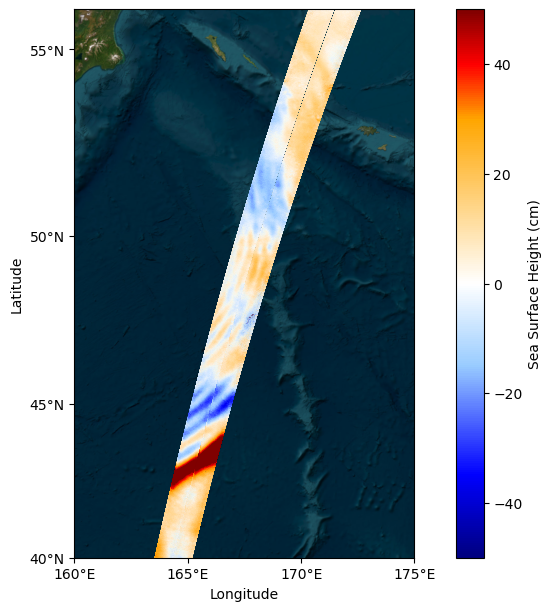

In [ ]:
# === Plot ===
fig, ax = plt.subplots(1, 1, figsize=(5.5,6), constrained_layout=True)

# === Load basemap ===
img, ext = cx.bounds2img(x0, y0, x1, y1, ll=False, source=cx.providers.Esri.WorldImagery, zoom=7)

# === Here we are plotting the SWOT SSHA + cross-over correction in cm ===
ax.imshow(img, extent=ext, interpolation='bilinear', zorder=0)
sc_left = ax.scatter(x_swot_left, y_swot_left, c=100*corrected_left, cmap=custom_cmap, vmin=-50, vmax=50, s=1, alpha=1)
sc_right = ax.scatter(x_swot_right, y_swot_right, c=100*corrected_right, cmap=custom_cmap, vmin=-50, vmax=50, s=1, alpha=1)

ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
lon_ticks = np.arange(lon_min, lon_max + 1, 5)
x_ticks = [transformer.transform(l - 360, lat_min)[0] for l in lon_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{int(l)}°E" for l in lon_ticks])
lat_ticks = np.arange(lat_min, lat_max + 1, 5)
y_ticks = [transformer.transform(lon_min_proj, l)[1] for l in lat_ticks]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{int(l)}°N" for l in lat_ticks])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cbar = fig.colorbar(sc_left, ax=ax, label='Sea Surface Height (cm)')

# Save (uncomment if you want to save the figure)
# plt.savefig("kamchatka_swot_map_highres.png", dpi=600)